# 14 — Card Detection Model Comparison

Side-by-side evaluation of two card detection models on the same input image.

| | Model | Source | Output | Confidence on our imgs |
|---|---|---|---|---|
| **A** | Our OBB model | `backend/models/yolo_obb_best.pt` (local) | Oriented bbox polygon | 0.62–0.92 |
| **C** | general-segmentation-api-6 | Roboflow Workflow (your workspace) | Segmentation polygon (rounded corners) | ~0.84 |

> **Model B (pokemon-card-detector-cuyon) was dropped** — it only scored ~0.06 on our images and gave axis-aligned boxes only. Not useful.

Both run via **plain HTTP `requests`** — no `inference-sdk` (it caps at Python <3.13; this machine has only 3.13/3.14).

### Kernel
Any Python with `ultralytics`, `opencv`, `requests`, `matplotlib` — the default **anaconda3 (3.13)** kernel has all of them.

In [1]:
import os, json, base64, tempfile
import requests
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

# ── Config ───────────────────────────────────────────────────────────
# Roboflow API key — loaded from gitignored .env.local / backend/.env (never committed).
# Override by exporting ROBOFLOW_API_KEY, or set it inline for a quick local test.
try:
    from dotenv import load_dotenv as _ld
    for _p in ("../.env.local", "../backend/.env", ".env.local"):
        _ld(_p, override=False)
except Exception:
    pass
#ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "")
ROBOFLOW_API_KEY = "nhuURuK4ToFkKABzGjCv"
assert ROBOFLOW_API_KEY, "ROBOFLOW_API_KEY not set — add it to .env.local or set it inline."

NOTEBOOKS_DIR = Path(".")
OBB_WEIGHTS   = NOTEBOOKS_DIR / "../backend/models/yolo_obb_best.pt"
ARTIFACTS_DIR = NOTEBOOKS_DIR / "artifacts"; ARTIFACTS_DIR.mkdir(exist_ok=True)

# Model B — cuyon (hosted object-detection model)
#   Endpoint: detect.roboflow.com/{PROJECT}/{VERSION}   (NO workspace slug here!)
CUYON_PROJECT = "pokemon-card-detector-cuyon"
CUYON_VERSION = 1

# Model C — your segmentation Workflow
#   Endpoint: serverless.roboflow.com/infer/workflows/{WORKSPACE}/{WORKFLOW_ID}
SEG_WORKSPACE = "srinivas-doddi"
SEG_WORKFLOW  = "general-segmentation-api-6"
SEG_CLASSES   = "card"   # text prompt; add set names e.g. "card, Ancient Origins, Aquapolis"

# Test images
#TEST_IMAGES = sorted(NOTEBOOKS_DIR.glob("card1_front*.png"))[:1]
TEST_IMAGES = sorted(NOTEBOOKS_DIR.glob("*.jpeg"))[:1]

print (TEST_IMAGES)
if not TEST_IMAGES:
    TEST_IMAGES = sorted(NOTEBOOKS_DIR.glob("cards/*.jpg"))[:1]

print ("NOTE: ", NOTEBOOKS_DIR)

print(f"OBB weights : {OBB_WEIGHTS.resolve()}  (exists={OBB_WEIGHTS.exists()})")
print(f"Test images : {[p.name for p in TEST_IMAGES]}")

[PosixPath('image0_back.jpeg')]
NOTE:  .
OBB weights : /Users/srinivasdoddi/srini/agentic-card-seller-os/backend/models/yolo_obb_best.pt  (exists=True)
Test images : ['image0_back.jpeg']


---
## ✅ Setup Verification
Confirms all three models are reachable **before** running inference. Run this first.

In [2]:
def _probe_img_b64():
    if not TEST_IMAGES:
        return None
    _img = cv2.imread(str(TEST_IMAGES[0]))
    _, buf = cv2.imencode(".jpg", _img)
    return base64.b64encode(buf).decode()

print("=" * 66)
print("SETUP VERIFICATION")
print("=" * 66)
_b64 = _probe_img_b64()

# ── A: local OBB weights ──
print("\n[A] Our OBB model (local file)")
if OBB_WEIGHTS.exists():
    print(f"    ✅ {OBB_WEIGHTS.name}  ({OBB_WEIGHTS.stat().st_size/1e6:.1f} MB)")
else:
    print(f"    ❌ NOT FOUND: {OBB_WEIGHTS.resolve()}")

# ── C: segmentation workflow ──
print("\n[C] general-segmentation-api-6  (serverless workflow)")
if _b64:
    try:
        r = requests.post(
            f"https://serverless.roboflow.com/infer/workflows/{SEG_WORKSPACE}/{SEG_WORKFLOW}",
            json={"api_key": ROBOFLOW_API_KEY,
                  "inputs": {"image": {"type": "base64", "value": _b64}, "classes": SEG_CLASSES},
                  "use_cache": True},
            timeout=60)
        if r.ok:
            preds = r.json()["outputs"][0].get("predictions", {}).get("predictions", [])
            print(f"    ✅ HTTP 200 — {len(preds)} segment(s)")
        else:
            print(f"    ❌ HTTP {r.status_code} — {r.text[:120]}")
    except Exception as e:
        print(f"    ❌ {type(e).__name__}: {e}")

print("\n" + "=" * 66)

SETUP VERIFICATION

[A] Our OBB model (local file)
    ✅ yolo_obb_best.pt  (5.7 MB)

[C] general-segmentation-api-6  (serverless workflow)
    ✅ HTTP 200 — 1 segment(s)



---
## Model A — Our OBB Model (local)
Oriented bounding box → 4-corner polygon that rotates with the card.

In [3]:
from ultralytics import YOLO

model_a = YOLO(str(OBB_WEIGHTS))
print(f"Model A — task: {model_a.task}   classes: {model_a.names}")


def run_model_a(img_bgr, conf_thresh=0.25):
    """Returns list of {pts (4x2 ndarray), conf, cls_name}."""
    res = model_a(img_bgr, conf=conf_thresh, verbose=False)[0]
    dets = []
    if res.obb is not None and len(res.obb):
        for pts, conf, cls in zip(res.obb.xyxyxyxy.cpu().numpy(),
                                  res.obb.conf.cpu().numpy(),
                                  res.obb.cls.cpu().numpy().astype(int)):
            dets.append({"pts": pts, "conf": float(conf), "cls_name": model_a.names[cls]})
    return dets


if TEST_IMAGES:
    _d = run_model_a(cv2.imread(str(TEST_IMAGES[0])))
    print(f"Smoke test ({TEST_IMAGES[0].name}): {len(_d)} det(s) — "
          + ", ".join(f"{x['cls_name']}={x['conf']:.2f}" for x in _d))

Model A — task: obb   classes: {0: 'pokemon_card'}
Smoke test (image0_back.jpeg): 2 det(s) — pokemon_card=0.92, pokemon_card=0.87


---
## Model C — general-segmentation-api-6 (your Roboflow Workflow)

Instance-**segmentation** workflow in your workspace. Returns polygon `points` per detection plus an `annotated_image`. Much stronger than cuyon on our images (~0.84 confidence).

**Endpoint:** `serverless.roboflow.com/infer/workflows/{WORKSPACE}/{WORKFLOW_ID}` (POST JSON).  
The `classes` text prompt steers what it segments (default `"card"`).

In [4]:
def run_model_c(img_bgr, classes=SEG_CLASSES, debug=False, want_annotated=False):
    """
    Run the segmentation workflow.

    Returns (dets, annotated_bgr):
        dets: list of {poly (Nx2 ndarray), x, y, w, h, conf, class_id}
        annotated_bgr: the workflow's pre-drawn image (BGR ndarray) or None
    """
    oh, ow = img_bgr.shape[:2]
    _, buf = cv2.imencode(".jpg", img_bgr)
    b64 = base64.b64encode(buf).decode()

    r = requests.post(
        f"https://serverless.roboflow.com/infer/workflows/{SEG_WORKSPACE}/{SEG_WORKFLOW}",
        json={"api_key": ROBOFLOW_API_KEY,
              "inputs": {"image": {"type": "base64", "value": b64}, "classes": classes},
              "use_cache": True},
        timeout=60)
    r.raise_for_status()
    out = r.json()["outputs"][0]

    pred_block = out.get("predictions", {})
    iw = pred_block.get("image", {}).get("width", ow)
    ih = pred_block.get("image", {}).get("height", oh)
    sx, sy = ow / iw, oh / ih
    preds = pred_block.get("predictions", [])

    if debug:
        print(f"    [C] {len(preds)} segment(s); scale=({sx:.3f},{sy:.3f})")

    dets = []
    for p in preds:
        poly = np.array([[pt["x"]*sx, pt["y"]*sy] for pt in p.get("points", [])], dtype=float)
        dets.append({"poly": poly,
                     "x": p["x"]*sx, "y": p["y"]*sy, "w": p["width"]*sx, "h": p["height"]*sy,
                     "conf": p["confidence"], "class_id": p.get("class_id", 0)})

    annotated = None
    if want_annotated and out.get("annotated_image", {}).get("value"):
        raw = base64.b64decode(out["annotated_image"]["value"])
        annotated = cv2.imdecode(np.frombuffer(raw, np.uint8), cv2.IMREAD_COLOR)
    return dets, annotated


if TEST_IMAGES:
    _d, _ann = run_model_c(cv2.imread(str(TEST_IMAGES[0])), debug=True)
    print(f"Smoke test: {len(_d)} segment(s) — "
          + ", ".join(f"conf={x['conf']:.2f} ({len(x['poly'])} pts)" for x in _d))

    [C] 1 segment(s); scale=(1.000,1.000)
Smoke test: 1 segment(s) — conf=0.85 (509 pts)


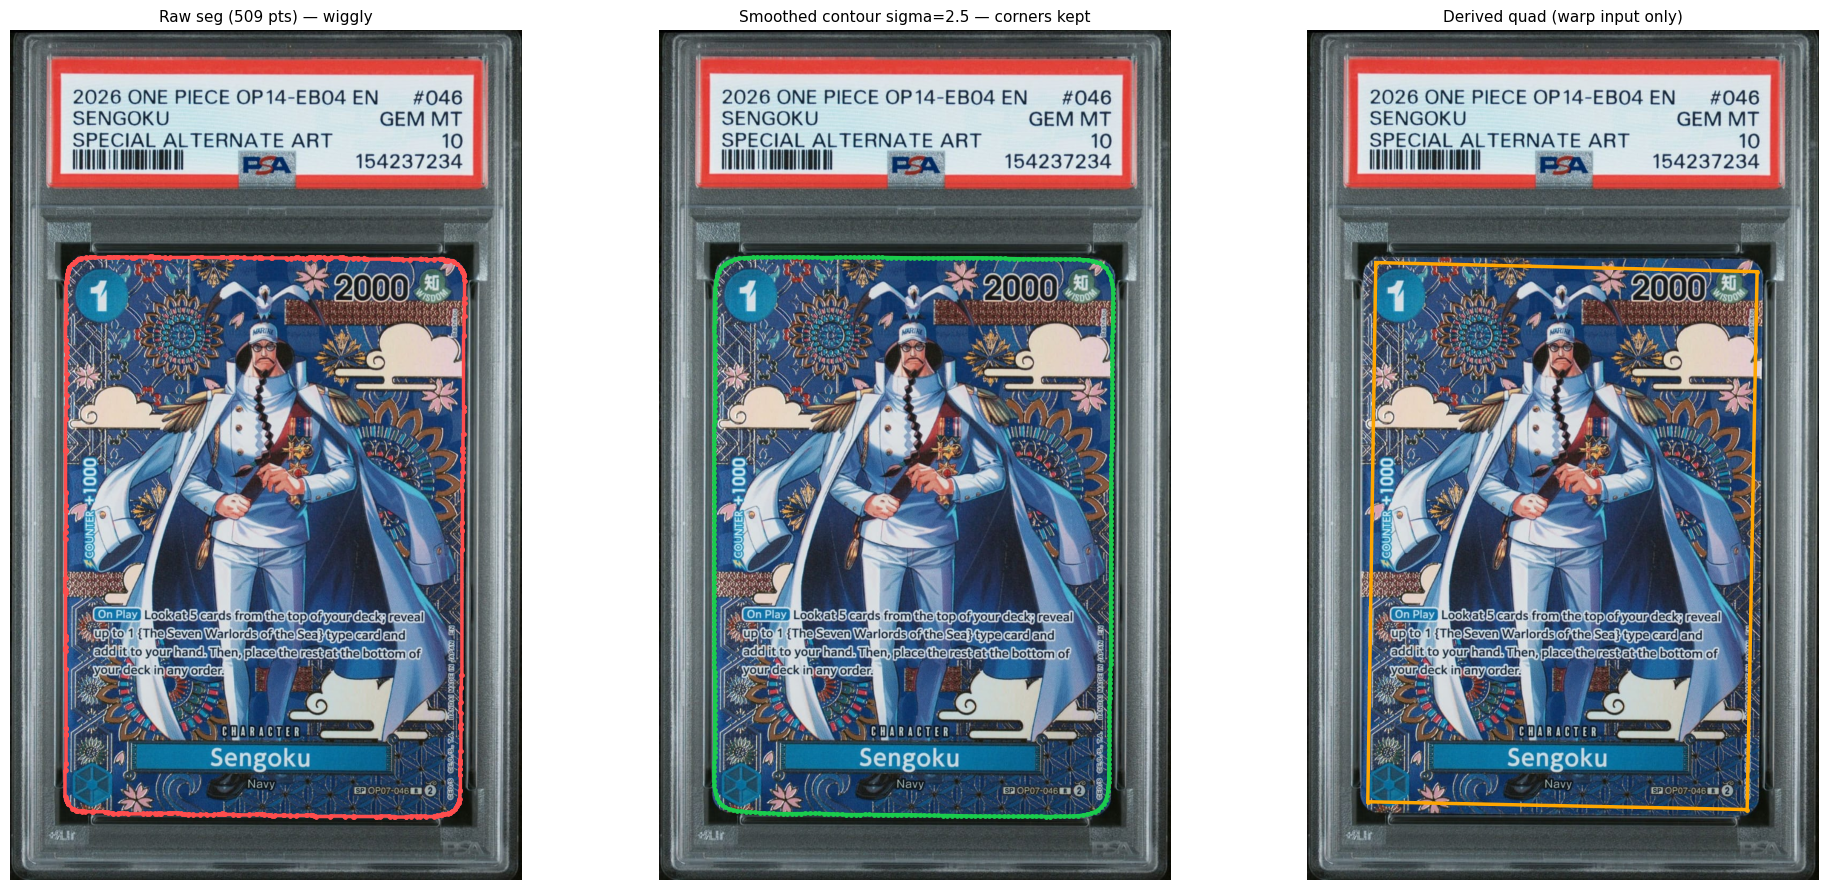

In [5]:
# ── Boundary smoothing for Model C (corner-preserving) ───────────────────────
# Model C's raw contour is a dense pixel trace → "wiggly" edges (jpeg staircase).
# A real card has ROUNDED corners, so instead of collapsing to a hard 4-pt quad
# (which fakes sharp 90° angles) we LOW-PASS smooth the contour: this kills the
# edge wiggle while PRESERVING the true corner curvature — better for Claude's
# corner-condition read. These are the exact functions the backend now uses
# (backend/card_segmenter.py), so the notebook and grader.py stay in sync.
import sys, importlib
sys.path.insert(0, "../backend")
import card_segmenter; importlib.reload(card_segmenter)
from card_segmenter import smooth_contour, quad_from_contour

def compare_smoothing(image_path, sigma=2.5):
    """Raw wiggly contour  vs  corner-preserving smooth  vs  derived warp-quad."""
    img = cv2.imread(str(image_path)); rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    dets, _ = run_model_c(img)
    if not dets:
        print("No segmentation for", image_path); return
    raw  = max(dets, key=lambda d: d["conf"])["poly"]
    sm   = smooth_contour(raw, sigma=sigma)            # keeps rounded corners
    quad = quad_from_contour(sm)                        # only for perspective warp

    variants = [("Raw seg (%d pts) — wiggly"               % len(raw), raw,                         (1, .3, .3)),
                ("Smoothed contour sigma=%.1f — corners kept" % sigma,  sm,                          (.1, .8, .3)),
                ("Derived quad (warp input only)",                      np.vstack([quad, quad[:1]]), (1, .65, 0))]
    fig, ax = plt.subplots(1, 3, figsize=(20, 9))
    for a, (t, p, c) in zip(ax, variants):
        a.imshow(rgb); a.set_title(t, fontsize=11); a.axis("off")
        a.add_patch(Polygon(p, closed=True, fill=False, edgecolor=c, linewidth=2.5))
        a.scatter(p[:, 0], p[:, 1], s=6, color=c)
    plt.tight_layout(); plt.show()

# Tune sigma: ~2 keeps corners crisp, ~5 rounds them more.
if TEST_IMAGES:
    compare_smoothing(TEST_IMAGES[0], sigma=2.5)

---
## Comparison Visualization

1×3 row per image:
- **A** 🟢 Our OBB (oriented polygon)
- **C** 🔵 segmentation workflow (filled polygon)
- **Overlay** — both together

In [6]:
COLOR_A = (0.00, 0.86, 0.31)   # green  — Model A OBB
COLOR_C = (0.20, 0.55, 1.00)   # blue   — Model C segmentation

def _lbl(color):
    return dict(color=color, fontsize=7, fontweight="bold",
                bbox=dict(boxstyle="square,pad=0.1", fc="black", alpha=0.6))


def _draw_a(ax, dets, label=True):
    for d in dets:
        ax.add_patch(Polygon(d["pts"], closed=True, fill=False, edgecolor=COLOR_A, linewidth=2.5))
        if label:
            ax.text(d["pts"][0,0], d["pts"][0,1]-10, f"A {d['conf']:.2f}", **_lbl("lime"))


def _draw_c(ax, dets, label=True):
    for d in dets:
        if len(d["poly"]):
            ax.add_patch(Polygon(d["poly"], closed=True, fill=True,
                                 edgecolor=COLOR_C, facecolor=COLOR_C, alpha=0.22, linewidth=2.0))
            ax.add_patch(Polygon(d["poly"], closed=True, fill=False, edgecolor=COLOR_C, linewidth=2.0))
            if label:
                ax.text(d["poly"][0,0], d["poly"][0,1]-10, f"C {d['conf']:.2f}", **_lbl("deepskyblue"))


def compare_models(image_path, conf_a=0.25, save=True):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f"⚠️  Could not read {image_path}"); return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    print(f"\n{'─'*66}\nImage: {Path(image_path).name}  ({img_rgb.shape[1]}×{img_rgb.shape[0]})")

    dets_a = run_model_a(img_bgr, conf_thresh=conf_a)
    print(f"  [A] {len(dets_a)} det(s): " + (", ".join(f"{d['conf']:.2f}" for d in dets_a) or "none"))
    try:
        dets_c, _ = run_model_c(img_bgr)
        print(f"  [C] {len(dets_c)} seg(s): " + (", ".join(f"{d['conf']:.2f}" for d in dets_c) or "none"))
    except Exception as e:
        print(f"  [C] ERROR: {e}"); dets_c = []

    fig, axes = plt.subplots(1, 3, figsize=(21, 9))
    fig.suptitle(f"Card Detection Comparison — {Path(image_path).name}",
                 fontsize=14, fontweight="bold", y=1.01)
    titles = ["A — Our OBB (local)  [oriented bbox]",
              "C — segmentation workflow  [polygon mask]",
              "Overlay — A 🟢  C 🔵"]
    for ax, t in zip(axes, titles):
        ax.imshow(img_rgb); ax.set_title(t, fontsize=10); ax.axis("off")

    _draw_a(axes[0], dets_a)
    _draw_c(axes[1], dets_c)
    _draw_a(axes[2], dets_a, label=False)
    _draw_c(axes[2], dets_c, label=False)

    for ax, dets, msg in [(axes[0], dets_a, "A: none"), (axes[1], dets_c, "C: none")]:
        if not dets:
            ax.text(0.5, 0.5, msg, transform=ax.transAxes, ha="center", va="center",
                    color="red", fontsize=14, fontweight="bold")

    axes[2].legend(handles=[
        Line2D([0],[0], color="lime",        lw=2.5, ls="-", label=f"A — OBB ({len(dets_a)})"),
        Line2D([0],[0], color="deepskyblue", lw=2.5, ls="-", label=f"C — seg ({len(dets_c)})"),
    ], loc="upper right", fontsize=9, framealpha=0.8, facecolor="black", labelcolor="white")

    plt.tight_layout()
    if save:
        out = ARTIFACTS_DIR / f"compare_{Path(image_path).stem}.png"
        plt.savefig(out, dpi=140, bbox_inches="tight"); print(f"  Saved → {out}")
    plt.show()


print("compare_models() ready.")

compare_models() ready.


In [12]:
from glob import glob
# Test images
#TEST_IMAGES = sorted(NOTEBOOKS_DIR.glob("card1_front*.png"))[:1]
path = "/Users/srinivasdoddi/srini/card-solutoin-testing/ungraded/ex_17_front.png"
TEST_IMAGES = sorted(glob(path))[:1]

print (TEST_IMAGES)

['/Users/srinivasdoddi/srini/card-solutoin-testing/ungraded/ex_17_front.png']


---
## Run on All Test Images


──────────────────────────────────────────────────────────────────
Image: ex_17_front.png  (589×739)
  [A] 1 det(s): 0.92
  [C] 1 seg(s): 0.93


/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_89380/3499865528.py:65: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_89380/3499865528.py:65: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_89380/3499865528.py:68: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=140, bbox_inches="tight"); print(f"  Saved → {out}")
/var/folders/5p/06nrcb_92mn1k91012g1flm40000gn/T/ipykernel_89380/3499865528.py:68: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=140, bbox_inches="tight"); print(f"  Saved → {out}")


  Saved → artifacts/compare_ex_17_front.png


/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


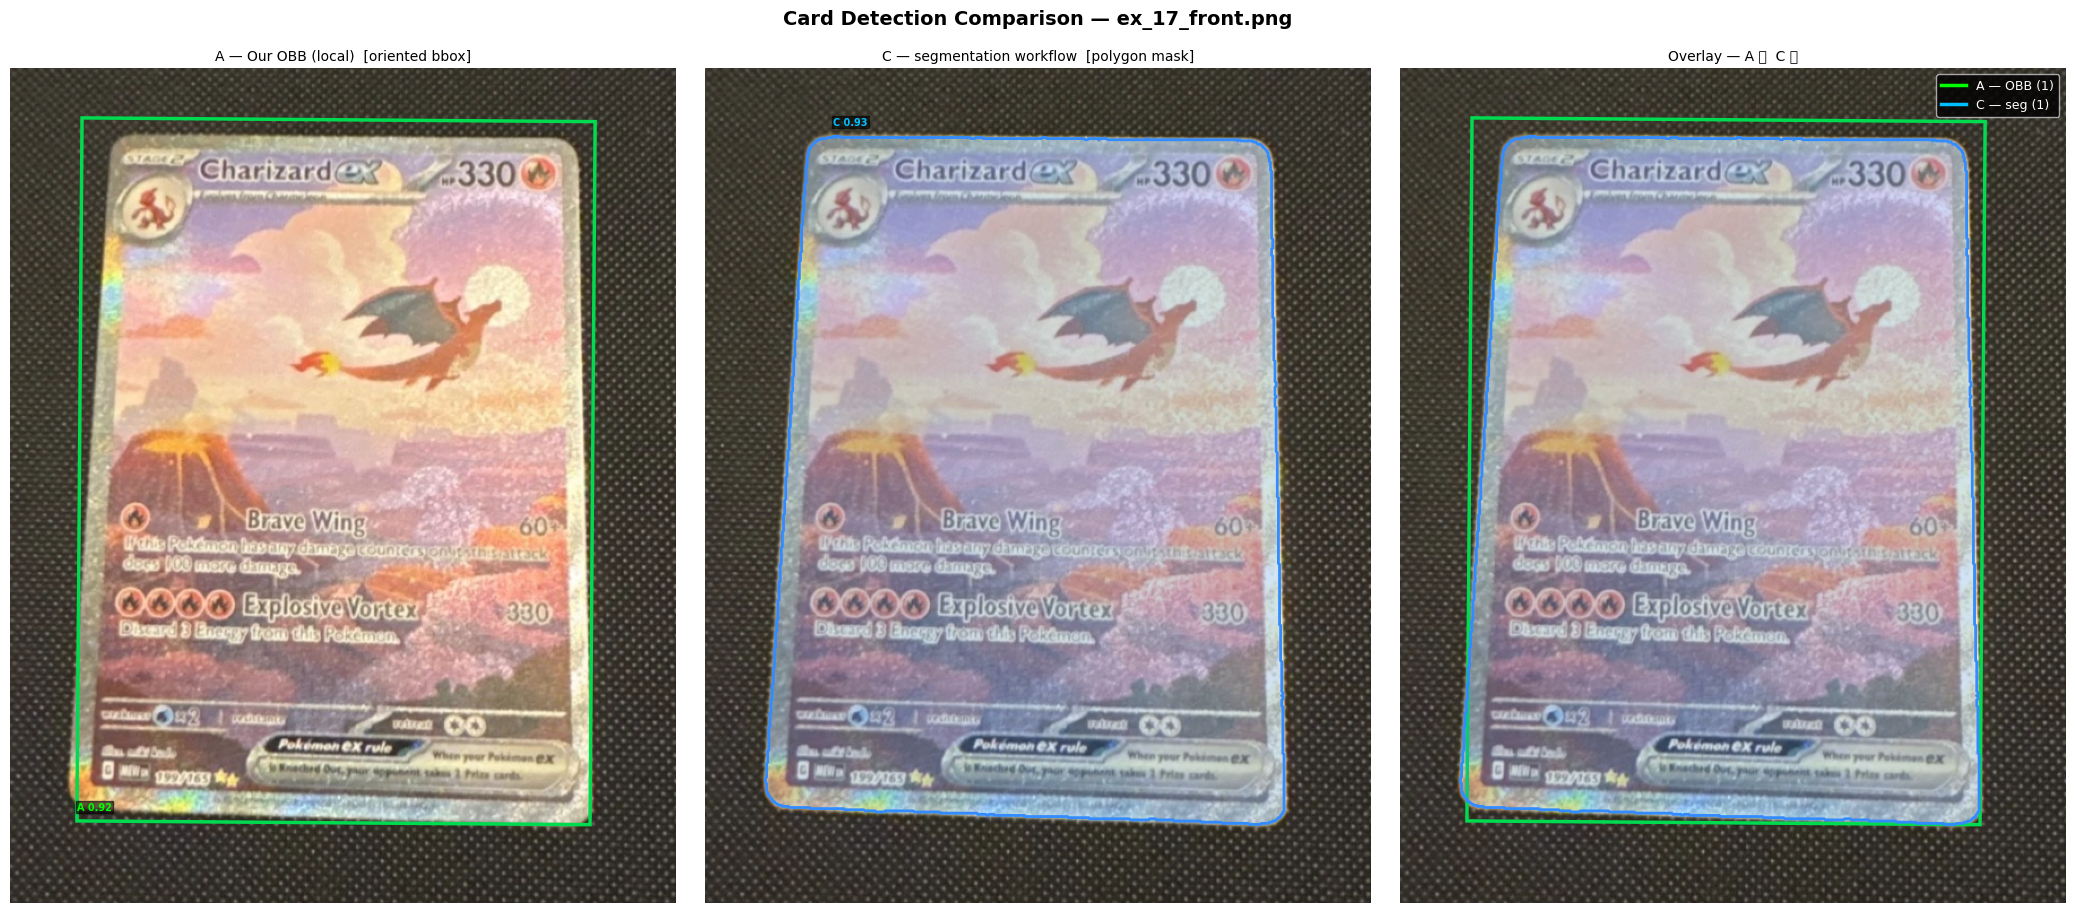

In [13]:
if not TEST_IMAGES:
    print("⚠️  No test images. Add image*_front.jpeg to notebooks/ or edit TEST_IMAGES.")
else:
    for p in TEST_IMAGES:
        compare_models(p)

---
## Test on a Custom Image

In [14]:
# Local file:
# compare_models("/path/to/card.jpg")

# From a URL:
# import urllib.request
# with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
#     urllib.request.urlretrieve("https://...", tmp.name)
#     compare_models(tmp.name)

print("Uncomment an example above to test a custom image.")

Uncomment an example above to test a custom image.


---
## (Optional) Show Model C's Pre-Annotated Image
The workflow returns its own rendered overlay — a sanity check against our re-drawn polygon.

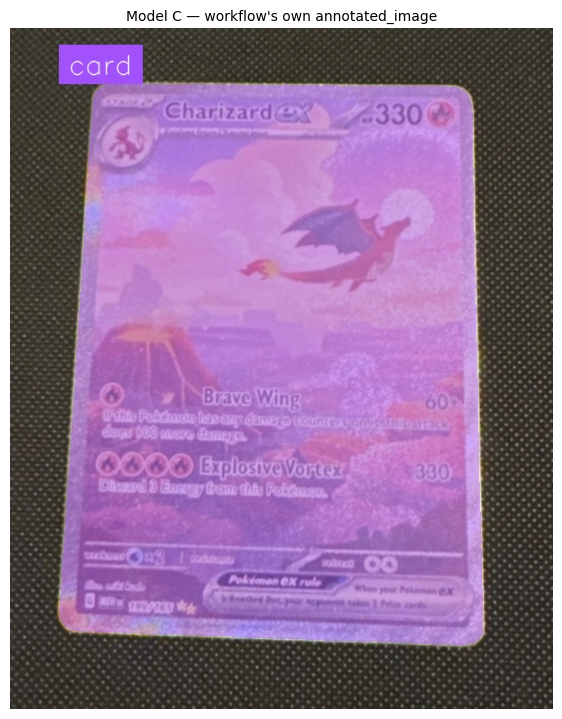

In [15]:
if TEST_IMAGES:
    _, ann = run_model_c(cv2.imread(str(TEST_IMAGES[0])), want_annotated=True)
    if ann is not None:
        plt.figure(figsize=(7, 11))
        plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        plt.title("Model C — workflow's own annotated_image", fontsize=10)
        plt.axis("off"); plt.show()
    else:
        print("No annotated_image returned.")

---
## Analysis & Next Steps

| Model | Output | Conf (our imgs) | Notes |
|---|---|---|---|
| **A — Our OBB** | oriented 4-pt polygon | 0.62–0.92 ✅ | Native oriented quad; can clip rounded corners / lock onto slab labels |
| **C — seg workflow** | pixel polygon mask | ~0.84 ✅ | Tight outline incl. real rounded corners; smoothed via `card_segmenter.smooth_contour` |

### Decision
- **C is the winner** — accurate outline that keeps the card's true rounded corners. Smoothed contour (corner-preserving low-pass) feeds both the boundary overlay and, via `quad_from_contour`, the perspective warp.
- **A** stays available as the default/fallback detector.
- **B (cuyon)** dropped — too weak (~0.06).

### Wired into the backend
`backend/card_segmenter.py` (`segment_card`, `smooth_contour`, `quad_from_contour`) + `backend/grader.py` `CARD_DETECTOR` env (`yolo` | `seg` | `seg_then_yolo`). `grade_card` returns `_card_contour_warped` (smoothed, rounded-corner outline in warped-normalised space). Enable with `CARD_DETECTOR=seg` (or `seg_then_yolo`) + `ROBOFLOW_API_KEY`.